In [ ]:
import pandas as pd
import numpy as np
import nltk
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
)

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report

nltk.download('stopwords')
nltk.download('wordnet')

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [47]:
fake = pd.read_csv("fake.csv")
true = pd.read_csv("true.csv")

print(fake.head())
print(true.head())

print(fake.shape)
print(true.shape)

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept t

In [48]:

display(fake.head())
display(true.head())

print(fake.shape)
print(true.shape)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


(23481, 4)
(21417, 4)


In [49]:
print(fake.duplicated().sum())
print(true.duplicated().sum())

3
206


In [50]:
fake.drop_duplicates(inplace=True)
true.drop_duplicates(inplace=True)
print(fake.duplicated().sum())
print(true.duplicated().sum())

0
0


In [51]:
fake.isnull().sum() 
true.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [52]:
fake["label"] = 0
true["label"] = 1

data = pd.concat([fake, true], axis=0)

data = data.sample(frac=1).reset_index(drop=True)

data.head()

,title,text,subject,date,label
0,U.N. chief says no alternative to two state so...,UNITED NATIONS (Reuters) - United Nations Secr...,worldnews,"December 6, 2017",1
1,Egypt says suspended U.S. military exercises t...,CAIRO (Reuters) - Egypt s armed forces said on...,worldnews,"September 5, 2017",1
2,Trump’s Approval Rating Took A HUGE Nosedive ...,Trump just can t get anything off the ground f...,News,"May 11, 2017",0
3,"Ahead of Trump's visit to Philippines, a big t...","SUBIC, Philippines (Reuters) - U.S. President ...",worldnews,"November 11, 2017",1
4,LIST OF 20 “Vetted” Refugees Who Were Charged ...,While the lying media is perpetuating the lie ...,politics,"Jan 29, 2017",0


In [53]:
data.duplicated().sum()

np.int64(0)

In [54]:
data = data.drop(["subject", "date"], axis=1)

data.head()

,title,text,label
0,U.N. chief says no alternative to two state so...,UNITED NATIONS (Reuters) - United Nations Secr...,1
1,Egypt says suspended U.S. military exercises t...,CAIRO (Reuters) - Egypt s armed forces said on...,1
2,Trump’s Approval Rating Took A HUGE Nosedive ...,Trump just can t get anything off the ground f...,0
3,"Ahead of Trump's visit to Philippines, a big t...","SUBIC, Philippines (Reuters) - U.S. President ...",1
4,LIST OF 20 “Vetted” Refugees Who Were Charged ...,While the lying media is perpetuating the lie ...,0


In [55]:
data["content"] = data["title"] + " " + data["text"]

data[["content", "label"]].head()

,content,label
0,U.N. chief says no alternative to two state so...,1
1,Egypt says suspended U.S. military exercises t...,1
2,Trump’s Approval Rating Took A HUGE Nosedive ...,0
3,"Ahead of Trump's visit to Philippines, a big t...",1
4,LIST OF 20 “Vetted” Refugees Who Were Charged ...,0


In [56]:
data.isnull().sum()

title      0
text       0
label      0
content    0
dtype: int64

In [57]:
print(data["title"].value_counts())

title
Factbox: Trump fills top jobs for his administration                                                     14
Factbox: Contenders for senior jobs in Trump's administration                                             8
Factbox: International reaction to arrest of Reuters reporters in Myanmar                                 6
MEDIA IGNORES Time That Bill Clinton FIRED His FBI Director On Day Before Vince Foster Was Found Dead     6
Factbox: Contenders, picks for key jobs in Trump's administration                                         5
                                                                                                         ..
North Korea sentences South Korean reporters to death over review of book about country                   1
Trump barnstorms to push healthcare plan; signs of conservative support                                   1
Democratic Representative Gutierrez hints at 2020 U.S. presidential run                                   1
 What Trump Just Said 

In [58]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


nltk.download("stopwords")
nltk.download("wordnet")


stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


data["content"] = data["content"].fillna("")

data["content"] = data["content"].astype(str)

data["content"] = data["content"].str.lower()

data["content"] = data["content"].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

data["content"] = data["content"].apply(lambda x: x.split())

data["content"] = data["content"].apply(lambda words: [word for word in words if word not in stop_words])

data["content"] = data["content"].apply(lambda words: [lemmatizer.lemmatize(word) for word in words])

data["clean_content"] = data["content"].apply(lambda x: " ".join(x))

data[["clean_content", "label"]].head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_content,label
0,un chief say alternative two state solution mi...,1
1,egypt say suspended u military exercise resume...,1
2,trump approval rating took huge nosedive right...,0
3,ahead trump visit philippine big thumb u veter...,1
4,list vetted refugee charged terrorism entering...,0


In [59]:
X = data["clean_content"]
y = data["label"]
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_text, X_test_text, y_train, y_test = train_test_split(
    data["clean_content"], y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_text = vectorizer.fit_transform(X_train_text)
X_test_text = vectorizer.transform(X_test_text)

print("Train shape:", X_train_text.shape, " Test shape:", X_test_text.shape)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    data["clean_content"], y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_text = vectorizer.fit_transform(X_train_text)
X_test_text = vectorizer.transform(X_test_text)

X_train, X_test = X_train_text, X_test_text

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

print("Train shape:", X_train_text.shape, " Test shape:", X_test_text.shape)

Train shape: (35751, 5000)  Test shape: (8938, 5000)
Train shape: (35751, 5000)  Test shape: (8938, 5000)
Train shape: (35751, 5000)  Test shape: (8938, 5000)


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVC": LinearSVC(),
    "Passive Aggressive": PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        y_scores = model.decision_function(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_scores),
    })

    fitted_models[name] = (model, y_pred, y_scores)
    print(f"{name} done -> Accuracy: {results[-1]['Accuracy']:.4f}")

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
print("\nModel Comparison:\n", results_df)

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score




# Cross Validation for the best model (Random Forest)
cv_data = data.dropna(subset=["clean_content", "label"]).copy()

cv_data = cv_data[
    cv_data["clean_content"]
    .astype(str)
    .str.strip()
    .ne("")
]

# فحص البيانات
print("Missing texts:", cv_data["clean_content"].isna().sum())
print("Missing labels:", cv_data["label"].isna().sum())
print("Class distribution:")
print(cv_data["label"].value_counts())

# Pipeline
cv_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2)
    )),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Stratified Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross Validation
cv_scores = cross_val_score(
    cv_pipeline,
    cv_data["clean_content"],
    cv_data["label"],
    cv=cv,
    scoring="accuracy",
    n_jobs=1,
    error_score="raise"
)

print("\nCross Validation Accuracy:")
print(cv_scores)
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")


c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression done -> Accuracy: 0.9906
Multinomial Naive Bayes done -> Accuracy: 0.9492
Linear SVC done -> Accuracy: 0.9954
Passive Aggressive done -> Accuracy: 0.9955
Random Forest done -> Accuracy: 0.9984

Model Comparison:
                      Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0            Random Forest  0.998434   0.998350  0.998350  0.998350  0.999969
1       Passive Aggressive  0.995525   0.995987  0.994578  0.995282  0.999606
2               Linear SVC  0.995413   0.995518  0.994814  0.995166  0.999704
3      Logistic Regression  0.990602   0.988257  0.991985  0.990118  0.998957
4  Multinomial Naive Bayes  0.949206   0.947754  0.945073  0.946412  0.985891
Missing texts: 0
Missing labels: 0
Class distribution:
label
0    23478
1    21211
Name: count, dtype: int64

Cross Validation Accuracy:
[0.99798613 0.99798613 0.99820989 0.99865742 0.99742643]
Mean Accuracy: 0.9981
Standard Deviation: 0.0004



Best Model: Random Forest
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        Real       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



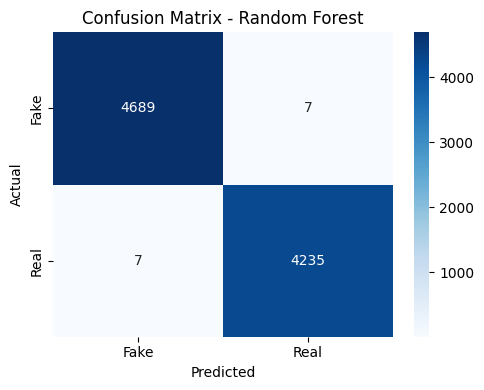

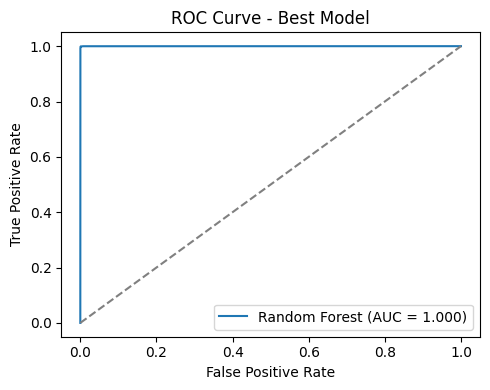

In [67]:
best_model_name = results_df.iloc[0]["Model"]
best_model, best_y_pred, best_y_scores = fitted_models[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(classification_report(y_test, best_y_pred, target_names=["Fake", "Real"]))

# Confusion Matrix
cm = confusion_matrix(y_test, best_y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, best_y_scores)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {results_df.iloc[0]['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Model")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()


In [ ]:
rf = fitted_models["Random Forest"][0]

train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

print("Train :", accuracy_score(y_train, train_pred))
print("Test  :", accuracy_score(y_test, test_pred))

Train : 1.0
Test  : 0.9984336540613112


In [ ]:
joblib.dump(best_model, "fake_news_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
print(f"\nSaved '{best_model_name}' -> fake_news_model.pkl")
print("Saved TF-IDF vectorizer -> tfidf_vectorizer.pkl")


Saved 'Random Forest' -> fake_news_model.pkl
Saved TF-IDF vectorizer -> tfidf_vectorizer.pkl
